First 5 rows:
  Student_ID Department  CGPA  Attendance  Backlogs  Internships  Projects  \
0     STU001       AIDS  7.87        86.7         1          2.0         2   
1     STU002       MECH  9.10        79.1         0          2.0         5   
2     STU003        ECE  8.36        86.7         1          1.0         1   
3     STU004         IT  7.14        90.9         1          0.0         3   
4     STU005        CSE  6.88        88.6         1          1.0         3   

   Aptitude_Score  Technical_Score  Communication_Score Placed  
0            64.9             88.3                 70.8    Yes  
1            63.0             97.2                 82.6    Yes  
2            81.7             72.4                 43.8    Yes  
3            70.3             60.2                 74.6    Yes  
4            77.9             64.3                 62.6    Yes  

Dataset Shape:
(503, 11)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data col

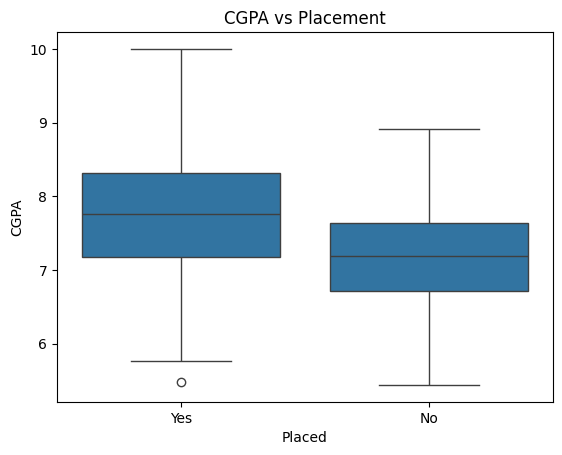


Average Internships by Placement:
Placed
No     0.986395
Yes    1.281690
Name: Internships, dtype: float64


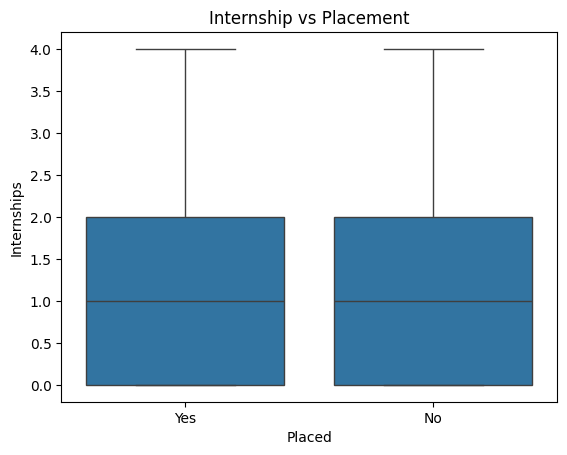


Average Projects by Placement:
Placed
No     2.074830
Yes    2.247191
Name: Projects, dtype: float64


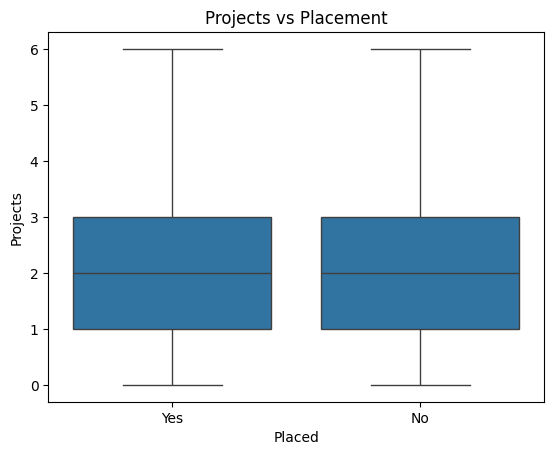


Average Technical Score by Placement:
Placed
No     62.599315
Yes    70.207887
Name: Technical_Score, dtype: float64


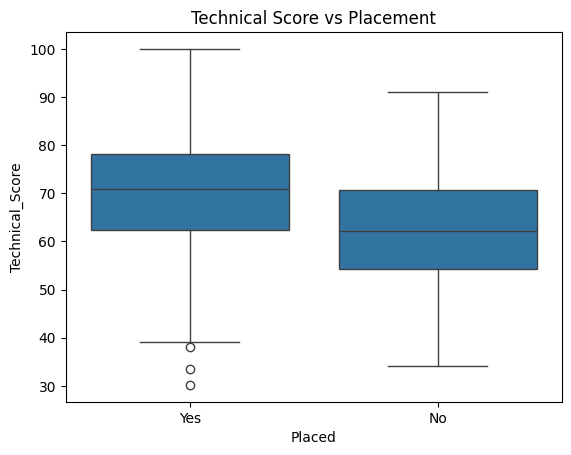


Average Attendance by Placement:
Placed
No     81.475172
Yes    82.872191
Name: Attendance, dtype: float64


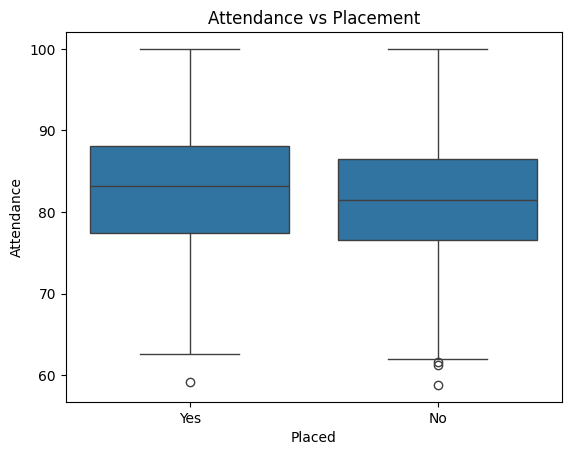

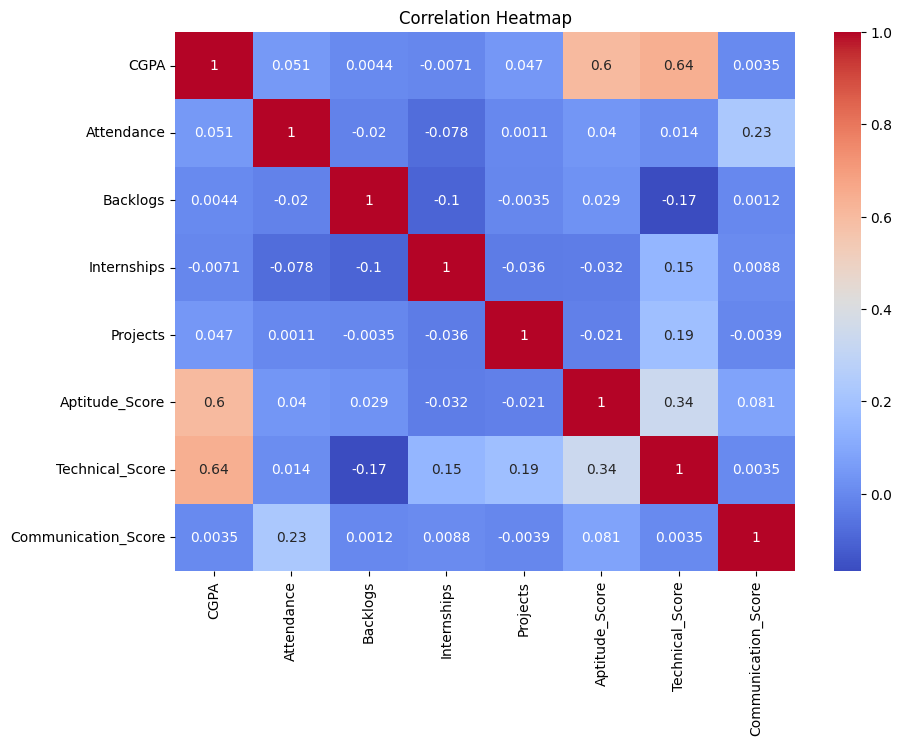


Placement Percentage by Department:
Placed             No        Yes
Department                      
AIDS        21.839080  78.160920
CSE         36.507937  63.492063
ECE         30.952381  69.047619
EEE         18.181818  81.818182
IT          28.048780  71.951220
MECH        33.333333  66.666667


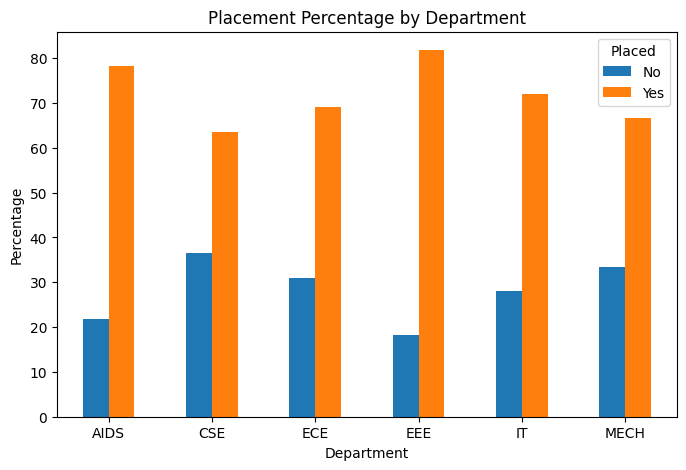


Candidate Features:
['Department', 'CGPA', 'Attendance', 'Backlogs', 'Internships', 'Projects', 'Aptitude_Score', 'Technical_Score', 'Communication_Score']

Target Variable:
Placed

Potential ML Problem:
Binary Classification


In [2]:
# ============================================
# STUDENT PLACEMENT ANALYTICS
# AI AUTOMATION - 01/10/2026
# ============================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load dataset
df = pd.read_csv("student_placement_500_analysis.csv")


# 3. Understand the data
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Information:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())


# 4. Missing values
print("\nMissing Values:")
print(df.isnull().sum())


# 5. Duplicate values
print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================
# T2 - PERFORMANCE ANALYSIS
# ============================================

# 6. Department-wise student count
print("\nDepartment-wise Student Count:")
print(df["Department"].value_counts())


# 7. Average CGPA by department
print("\nAverage CGPA by Department:")
print(
    df.groupby("Department")["CGPA"].mean()
)


# 8. Average aptitude score
print("\nAverage Aptitude Score:")
print(df["Aptitude_Score"].mean())


# 9. Average technical score
print("\nAverage Technical Score:")
print(df["Technical_Score"].mean())


# 10. Placement count
print("\nPlacement Count:")
print(df["Placed"].value_counts())


# 11. Placement percentage
if df["Placed"].dtype == "object":

    placement_percentage = (
        df["Placed"].value_counts(normalize=True) * 100
    )

    print("\nPlacement Percentage:")
    print(placement_percentage)

else:

    placement_percentage = df["Placed"].mean() * 100

    print("\nOverall Placement Percentage:")
    print(placement_percentage)


# 12. Performance score
df["Performance_Score"] = (
    df["CGPA"]
    + df["Aptitude_Score"]
    + df["Technical_Score"]
    + df["Communication_Score"]
) / 4


# 13. Top 10 students
top_10 = df.sort_values(
    "Performance_Score",
    ascending=False
).head(10)

print("\nTop 10 Students:")
print(
    top_10[
        [
            "Student_ID",
            "Department",
            "Performance_Score"
        ]
    ]
)


# ============================================
# T3 - EDA
# ============================================

# 14. CGPA vs Placement
print("\nAverage CGPA by Placement:")
print(
    df.groupby("Placed")["CGPA"].mean()
)

sns.boxplot(
    data=df,
    x="Placed",
    y="CGPA"
)

plt.title("CGPA vs Placement")
plt.show()


# 15. Internship vs Placement
print("\nAverage Internships by Placement:")
print(
    df.groupby("Placed")["Internships"].mean()
)

sns.boxplot(
    data=df,
    x="Placed",
    y="Internships"
)

plt.title("Internship vs Placement")
plt.show()


# 16. Projects vs Placement
print("\nAverage Projects by Placement:")
print(
    df.groupby("Placed")["Projects"].mean()
)

sns.boxplot(
    data=df,
    x="Placed",
    y="Projects"
)

plt.title("Projects vs Placement")
plt.show()


# 17. Technical Score vs Placement
print("\nAverage Technical Score by Placement:")
print(
    df.groupby("Placed")["Technical_Score"].mean()
)

sns.boxplot(
    data=df,
    x="Placed",
    y="Technical_Score"
)

plt.title("Technical Score vs Placement")
plt.show()


# 18. Attendance vs Placement
print("\nAverage Attendance by Placement:")
print(
    df.groupby("Placed")["Attendance"].mean()
)

sns.boxplot(
    data=df,
    x="Placed",
    y="Attendance"
)

plt.title("Attendance vs Placement")
plt.show()


# ============================================
# 19. Correlation
# ============================================

numeric_columns = [
    "CGPA",
    "Attendance",
    "Backlogs",
    "Internships",
    "Projects",
    "Aptitude_Score",
    "Technical_Score",
    "Communication_Score"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


# ============================================
# 20. Placement by Department
# ============================================

placement_by_department = pd.crosstab(
    df["Department"],
    df["Placed"],
    normalize="index"
) * 100

print("\nPlacement Percentage by Department:")
print(placement_by_department)

placement_by_department.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Placement Percentage by Department")
plt.ylabel("Percentage")
plt.xlabel("Department")
plt.xticks(rotation=0)

plt.show()


# ============================================
# 21. Candidate Features
# ============================================

features = [
    "Department",
    "CGPA",
    "Attendance",
    "Backlogs",
    "Internships",
    "Projects",
    "Aptitude_Score",
    "Technical_Score",
    "Communication_Score"
]

target = "Placed"

print("\nCandidate Features:")
print(features)

print("\nTarget Variable:")
print(target)

print("\nPotential ML Problem:")
print("Binary Classification")